In [1]:
import os, json, warnings, logging
from pathlib import Path
from typing import Optional, Tuple, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

PROJECT_ROOT = Path('.')
DATA_FEAT    = PROJECT_ROOT / 'data' / 'features'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
RESULTS      = PROJECT_ROOT / 'results' / 'plots'
SRC_DIR      = PROJECT_ROOT / 'src'
SRC_DIR.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.6f}'.format)

with open(DATA_FEAT / 'feature_config.json', 'r') as f:
    FEAT_CONFIG = json.load(f)

ALL_FEATURES    = FEAT_CONFIG['all_features']
REGIME_FEATURES = FEAT_CONFIG['regime_features']
N_FEATURES      = FEAT_CONFIG['n_features']
LOOKBACK        = FEAT_CONFIG['lookback_window']

wti_df = pd.read_parquet(DATA_FEAT / 'WTI_Crude_Oil_features.parquet')
with open(DATA_PROC / 'walkforward_splits.json', 'r') as f:
    SPLITS = json.load(f)

print(f'Loaded: {len(wti_df)} rows | {N_FEATURES} features | {len(SPLITS)} splits')

Loaded: 4965 rows | 47 features | 33 splits


In [2]:
ENV_CONFIG = {
    # Episode
    'episode_length'        : 250,
    'lookback_window'       : LOOKBACK,
    'n_features'            : N_FEATURES,
    # Action space
    'action_min'            : -1.0,
    'action_max'            :  1.0,
    # Portfolio
    'initial_capital'       : 100_000.0,
    'max_position_size'     : 1.0,
    'leverage_limit'        : 2.0,
    # Transaction costs (realistic WTI futures)
    'commission_per_trade'  : 0.0002,
    'bid_ask_spread'        : 0.0003,
    'slippage'              : 0.0001,
    'roll_cost'             : 0.0004,
    # Reward weights
    'w_return'              : 0.40,
    'w_sharpe'              : 0.30,
    'w_drawdown'            : 0.20,
    'w_transaction'         : 0.10,
    'reward_scaling'        : 100.0,
    'sharpe_window'         : 21,
    # Risk limits
    'max_drawdown_limit'    : -0.25,
    'position_change_limit' : 0.5,
    # Normalization
    'scaler_type'           : 'robust',
    'clip_obs'              : 5.0,
    'seed'                  : 42
}

print('ENV_CONFIG loaded.')
for k, v in ENV_CONFIG.items():
    print(f'  {k:30s}: {v}')

ENV_CONFIG loaded.
  episode_length                : 250
  lookback_window               : 60
  n_features                    : 47
  action_min                    : -1.0
  action_max                    : 1.0
  initial_capital               : 100000.0
  max_position_size             : 1.0
  leverage_limit                : 2.0
  commission_per_trade          : 0.0002
  bid_ask_spread                : 0.0003
  slippage                      : 0.0001
  roll_cost                     : 0.0004
  w_return                      : 0.4
  w_sharpe                      : 0.3
  w_drawdown                    : 0.2
  w_transaction                 : 0.1
  reward_scaling                : 100.0
  sharpe_window                 : 21
  max_drawdown_limit            : -0.25
  position_change_limit         : 0.5
  scaler_type                   : robust
  clip_obs                      : 5.0
  seed                          : 42


In [3]:
class CommodityTradingEnv(gym.Env):
    """
    Commodity Futures Trading Environment.
    State  : (lookback x n_features) + portfolio state
    Action : Continuous position in [-1, +1]
    Reward : Multi-objective risk-adjusted return
    Episode: 250 trading days
    """
    metadata = {'render_modes': ['human']}

    def __init__(self, df, features, config, mode='train', scaler=None, render_mode=None):
        super().__init__()
        self.df = df.copy()
        self.features = features
        self.config = config
        self.mode = mode
        self.render_mode = render_mode
        missing = [f for f in features if f not in df.columns]
        if missing:
            raise ValueError(f'Missing features: {missing}')
        self.n_features = len(features)
        self.lookback = config['lookback_window']
        self.episode_length = config['episode_length']
        self.n_rows = len(df)
        self.min_rows = self.lookback + self.episode_length
        if self.n_rows < self.min_rows:
            raise ValueError(f'Need {self.min_rows} rows, got {self.n_rows}')
        # Scaler
        if mode == 'train' or scaler is None:
            self.scaler = RobustScaler()
            self.scaler.fit(df[features].values)
        else:
            self.scaler = scaler
        # Pre-compute arrays
        scaled = self.scaler.transform(df[features].values)
        self.features_arr = np.clip(scaled, -config['clip_obs'], config['clip_obs']).astype(np.float32)
        self.close_arr  = df['close'].values.astype(np.float32)
        self.return_arr = df['log_return'].fillna(0).values.astype(np.float32)
        # Spaces
        obs_dim = self.lookback * self.n_features + 5
        self.observation_space = spaces.Box(
            low=-config['clip_obs'], high=config['clip_obs'],
            shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=np.array([config['action_min']], dtype=np.float32),
            high=np.array([config['action_max']], dtype=np.float32),
            shape=(1,), dtype=np.float32
        )
        self._init_state()

    def _init_state(self):
        self.current_step = 0
        self.start_idx = 0
        self.portfolio_value = float(self.config['initial_capital'])
        self.cash = self.portfolio_value
        self.position = 0.0
        self.peak_value = self.portfolio_value
        self.total_costs = 0.0
        self.trade_count = 0
        self.return_history = []
        self.value_history  = [self.portfolio_value]
        self.action_history = []
        self.reward_history = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        max_start = self.n_rows - self.episode_length - self.lookback
        if self.mode == 'train':
            self.start_idx = int(self.np_random.integers(0, max(1, max_start)))
        else:
            self.start_idx = 0
        self._init_state()
        return self._get_observation(), self._get_info()

    def step(self, action):
        new_pos = float(np.clip(action[0], self.config['action_min'], self.config['action_max']))
        max_change = self.config['position_change_limit']
        delta = np.clip(new_pos - self.position, -max_change, max_change)
        new_pos = self.position + delta
        cost = self._compute_cost(self.position, new_pos)
        data_idx = self.start_idx + self.lookback + self.current_step
        market_ret = float(self.return_arr[min(data_idx, len(self.return_arr)-1)])
        port_ret = self.position * market_ret - cost
        new_val = self.portfolio_value * (1 + port_ret)
        self.position = new_pos
        self.portfolio_value = new_val
        self.peak_value = max(self.peak_value, new_val)
        self.total_costs += cost * self.portfolio_value
        self.trade_count += 1 if abs(delta) > 0.01 else 0
        reward = self._compute_reward(port_ret, cost)
        self.return_history.append(port_ret)
        self.value_history.append(self.portfolio_value)
        self.action_history.append(new_pos)
        self.reward_history.append(reward)
        self.current_step += 1
        truncated  = self.current_step >= self.episode_length
        terminated = self._check_termination()
        return self._get_observation(), reward, terminated, truncated, self._get_info()

    def _compute_cost(self, old_pos, new_pos):
        trade_size = abs(new_pos - old_pos)
        if trade_size < 1e-6:
            return 0.0
        cost = trade_size * (
            self.config['commission_per_trade'] +
            self.config['bid_ask_spread'] +
            self.config['slippage']
        )
        if self.current_step % 21 == 0 and abs(new_pos) > 0.01:
            cost += abs(new_pos) * self.config['roll_cost']
        return float(cost)

    def _compute_reward(self, port_ret, cost):
        cfg = self.config
        r_return = port_ret
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        r_drawdown = min(drawdown, 0.0)
        r_transaction = -cost
        r_sharpe = 0.0
        w = cfg['sharpe_window']
        if len(self.return_history) >= w:
            rets = np.array(self.return_history[-w:])
            r_sharpe = np.clip(
                rets.mean() / (rets.std() + 1e-10) * np.sqrt(252/w),
                -5.0, 5.0
            )
        reward = (
            cfg['w_return']      * r_return +
            cfg['w_drawdown']    * r_drawdown +
            cfg['w_transaction'] * r_transaction +
            cfg['w_sharpe']      * r_sharpe * 0.01
        ) * cfg['reward_scaling']
        return float(reward)

    def _check_termination(self):
        if self.peak_value <= 0:
            return True
        return (self.portfolio_value / self.peak_value - 1) < self.config['max_drawdown_limit']

    def _get_observation(self):
        start = self.start_idx + self.current_step
        end   = start + self.lookback
        end   = min(end, len(self.features_arr))
        start = max(0, end - self.lookback)
        feat_window = self.features_arr[start:end]
        if len(feat_window) < self.lookback:
            pad = np.zeros((self.lookback - len(feat_window), self.n_features), dtype=np.float32)
            feat_window = np.vstack([pad, feat_window])
        drawdown = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        log_pnl  = np.log(self.portfolio_value / self.config['initial_capital'] + 1e-10)
        port_state = np.array([
            self.position,
            np.clip(drawdown, -1.0, 0.0),
            np.clip(log_pnl, -5.0, 5.0),
            self.current_step / self.episode_length,
            np.clip(self.total_costs / self.config['initial_capital'], 0, 0.1)
        ], dtype=np.float32)
        return np.concatenate([feat_window.flatten(), port_state]).astype(np.float32)

    def _get_info(self):
        dd = self.portfolio_value / self.peak_value - 1 if self.peak_value > 0 else 0.0
        tr = self.portfolio_value / self.config['initial_capital'] - 1
        sharpe = 0.0
        if len(self.return_history) >= self.config['sharpe_window']:
            rets = np.array(self.return_history)
            sharpe = rets.mean() / (rets.std() + 1e-10) * np.sqrt(252)
        return {
            'step': self.current_step,
            'portfolio_value': self.portfolio_value,
            'position': self.position,
            'total_return': tr,
            'drawdown': dd,
            'sharpe': sharpe,
            'total_costs': self.total_costs,
            'trade_count': self.trade_count
        }

    def get_episode_metrics(self):
        values  = np.array(self.value_history)
        returns = np.array(self.return_history)
        if len(returns) < 2:
            return {}
        total_return = values[-1] / values[0] - 1
        n_days = len(returns)
        ann_return = (1 + total_return) ** (252 / n_days) - 1
        ann_vol    = returns.std() * np.sqrt(252)
        sharpe     = ann_return / (ann_vol + 1e-10)
        peak       = np.maximum.accumulate(values)
        dd         = (values - peak) / (peak + 1e-10)
        max_dd     = dd.min()
        calmar     = ann_return / (abs(max_dd) + 1e-10)
        neg_rets   = returns[returns < 0]
        down_std   = neg_rets.std() * np.sqrt(252) if len(neg_rets) > 0 else 1e-10
        sortino    = ann_return / (down_std + 1e-10)
        win_rate   = (returns > 0).mean()
        return {
            'total_return': float(total_return),
            'ann_return'  : float(ann_return),
            'ann_vol'     : float(ann_vol),
            'sharpe'      : float(sharpe),
            'max_drawdown': float(max_dd),
            'calmar'      : float(calmar),
            'sortino'     : float(sortino),
            'win_rate'    : float(win_rate),
            'total_costs' : float(self.total_costs),
            'trade_count' : int(self.trade_count),
            'episode_length': int(len(returns))
        }

    def render(self):
        if self.render_mode == 'human':
            info = self._get_info()
            print(f"Step {info['step']:4d} | Value: ${info['portfolio_value']:10.2f} | "
                  f"Pos: {info['position']:+.3f} | Return: {info['total_return']:+.4f}")

    def close(self):
        pass

print('CommodityTradingEnv defined.')

CommodityTradingEnv defined.


In [4]:
class WalkForwardEnvFactory:
    """
    Creates train/test env pairs per walk-forward split.
    Scaler is ALWAYS fit on training window only.
    """
    def __init__(self, df, features, splits, config):
        self.df       = df
        self.features = features
        self.splits   = splits
        self.config   = config

    def get_split(self, split_idx):
        split = self.splits[split_idx]
        train_df = self.df[
            (self.df.index >= split['train_start']) &
            (self.df.index <  split['train_end'])
        ].copy()
        test_df = self.df[
            (self.df.index >= split['test_start']) &
            (self.df.index <  split['test_end'])
        ].copy()

        # Fit scaler on training data ONLY
        scaler = RobustScaler()
        scaler.fit(train_df[self.features].values)

        # Adapt episode length to available data
        # Test episode length = min(250, available_test_rows - lookback)
        test_config  = dict(self.config)
        train_config = dict(self.config)

        min_test_ep = len(test_df) - self.config['lookback_window']
        min_train_ep = len(train_df) - self.config['lookback_window']

        if min_test_ep < self.config['episode_length']:
            if min_test_ep < 20:
                print(f'  Split {split_idx}: test too small ({len(test_df)} rows), skipping.')
                return None, None, None
            test_config['episode_length'] = min_test_ep
            print(f'  Split {split_idx}: test episode length adapted to {min_test_ep}')

        if min_train_ep < self.config['episode_length']:
            train_config['episode_length'] = min_train_ep

        train_env = CommodityTradingEnv(
            train_df, self.features, train_config, 'train', scaler
        )
        test_env = CommodityTradingEnv(
            test_df, self.features, test_config, 'test', scaler
        )
        return train_env, test_env, scaler

    def n_splits(self):
        return len(self.splits)


factory = WalkForwardEnvFactory(wti_df, ALL_FEATURES, SPLITS, ENV_CONFIG)

# Find first usable split
train_env, test_env, scaler = None, None, None
for i in range(factory.n_splits()):
    te, te2, sc = factory.get_split(i)
    if te is not None:
        train_env, test_env, scaler = te, te2, sc
        print(f'\nUsing split {i} for validation.')
        break

print(f'Train rows: {train_env.n_rows} | Test rows: {test_env.n_rows}')
print(f'Obs shape : {train_env.observation_space.shape}')
print(f'Action    : {train_env.action_space}')

  Split 0: test episode length adapted to 70

Using split 0 for validation.
Train rows: 531 | Test rows: 130
Obs shape : (2825,)
Action    : Box(-1.0, 1.0, (1,), float32)


In [5]:
def run_random_agent(env, n_episodes=10):
    metrics_list = []
    for ep in range(n_episodes):
        obs, info = env.reset(seed=ep)
        assert not np.any(np.isnan(obs)), f'NaN in obs ep {ep}'
        total_reward = 0.0
        step = 0
        while True:
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            assert np.isfinite(reward), f'Non-finite reward step {step}'
            assert not np.any(np.isnan(obs)), f'NaN obs step {step}'
            total_reward += reward
            step += 1
            if terminated or truncated:
                break
        m = env.get_episode_metrics()
        m['total_reward'] = total_reward
        metrics_list.append(m)
        if ep in [0, n_episodes-1]:
            print(f'  Ep {ep+1}: Return={m.get("total_return",0):+.4f} | '
                  f'Sharpe={m.get("sharpe",0):+.3f} | '
                  f'MaxDD={m.get("max_drawdown",0):.4f} | Steps={step}')
    returns = [m.get('total_return',0) for m in metrics_list]
    print(f'\nRandom Agent Summary: mean_return={np.mean(returns):+.4f} std={np.std(returns):.4f}')
    return metrics_list


print('Running random agent validation (10 episodes)...')
val = run_random_agent(train_env)
print('\n✓ Environment validation passed')

Running random agent validation (10 episodes)...
  Ep 1: Return=-0.0988 | Sharpe=-0.865 | MaxDD=-0.2322 | Steps=250
  Ep 10: Return=+0.1173 | Sharpe=+1.001 | MaxDD=-0.0744 | Steps=250

Random Agent Summary: mean_return=-0.0511 std=0.0943

✓ Environment validation passed


In [6]:
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.vec_env import DummyVecEnv

print('Running SB3 environment check...')
check_instance = CommodityTradingEnv(wti_df, ALL_FEATURES, ENV_CONFIG, 'train')
check_env(check_instance, warn=True, skip_render_check=True)
print('✓ SB3 compatibility check passed')

# Vectorized environment test
def make_env(seed=0):
    def _init():
        env = CommodityTradingEnv(wti_df, ALL_FEATURES, ENV_CONFIG, 'train')
        env.reset(seed=seed)
        return env
    return _init

n_envs = 4
vec_env = DummyVecEnv([make_env(i) for i in range(n_envs)])
obs = vec_env.reset()
print(f'\nVectorized env: {n_envs} parallel | obs shape: {obs.shape}')
actions = np.array([[np.random.uniform(-1, 1)] for _ in range(n_envs)], dtype=np.float32)
obs, rewards, dones, infos = vec_env.step(actions)
print(f'Step rewards: {rewards.round(4)}')
print('✓ Vectorized environment works')
vec_env.close()

Running SB3 environment check...
✓ SB3 compatibility check passed

Vectorized env: 4 parallel | obs shape: (4, 2825)
Step rewards: [-0.035  -0.0011 -0.0101 -0.0346]
✓ Vectorized environment works


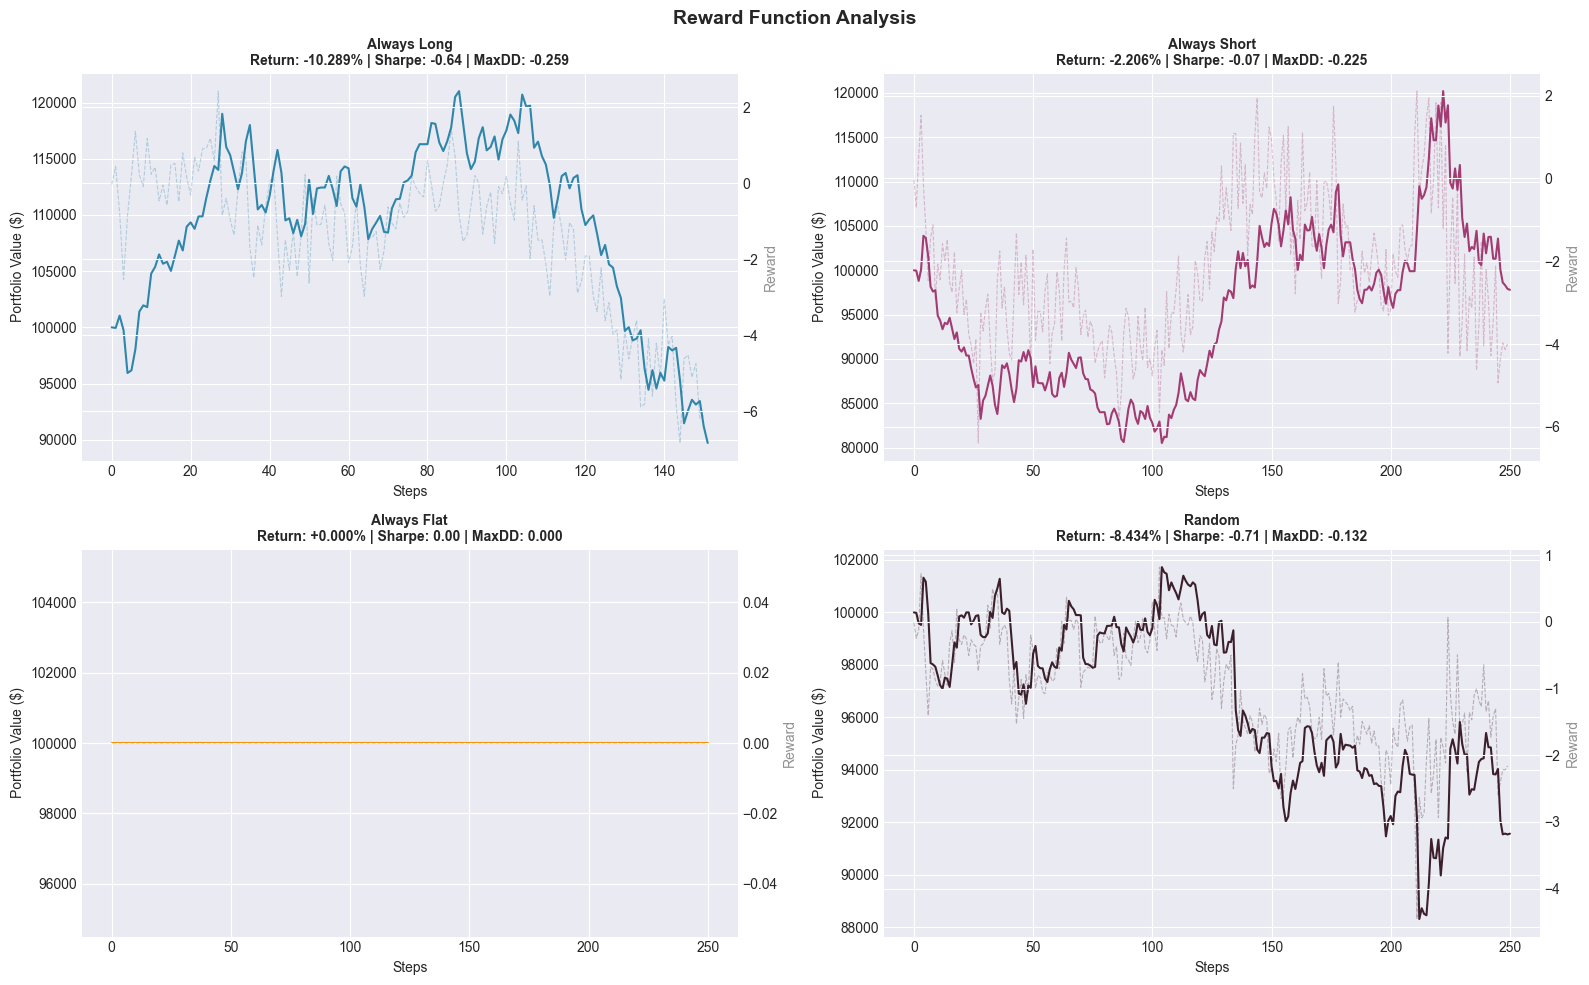


Strategy            Return   Sharpe    MaxDD
---------------------------------------------
Always Long        -0.1029   -0.642  -0.2587
Always Short       -0.0221   -0.075  -0.2249
Always Flat        +0.0000    0.000   0.0000
Random             -0.0843   -0.712  -0.1318


In [7]:
strategies = {
    'Always Long' : lambda s: np.array([1.0],  dtype=np.float32),
    'Always Short': lambda s: np.array([-1.0], dtype=np.float32),
    'Always Flat' : lambda s: np.array([0.0],  dtype=np.float32),
    'Random'      : lambda s: np.array([np.random.uniform(-1,1)], dtype=np.float32)
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#3B1F2B']
results = {}

for (name, strat), ax, color in zip(strategies.items(), axes.flatten(), colors):
    obs, _ = train_env.reset(seed=42)
    values, rewards = [ENV_CONFIG['initial_capital']], []
    for step in range(250):
        obs, reward, terminated, truncated, info = train_env.step(strat(step))
        values.append(info['portfolio_value'])
        rewards.append(reward)
        if terminated or truncated:
            break
    m = train_env.get_episode_metrics()
    results[name] = m
    ax2 = ax.twinx()
    ax.plot(values, color=color, linewidth=1.5)
    ax2.plot(rewards, color=color, alpha=0.3, linewidth=0.8, linestyle='--')
    ax.set_title(
        f'{name}\nReturn: {m.get("total_return",0):+.3%} | '
        f'Sharpe: {m.get("sharpe",0):.2f} | MaxDD: {m.get("max_drawdown",0):.3f}',
        fontweight='bold', fontsize=10
    )
    ax.set_xlabel('Steps')
    ax.set_ylabel('Portfolio Value ($)')
    ax2.set_ylabel('Reward', alpha=0.5)

plt.suptitle('Reward Function Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'reward_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{"Strategy":15s} {"Return":>10s} {"Sharpe":>8s} {"MaxDD":>8s}')
print('-' * 45)
for name, m in results.items():
    print(f'{name:15s} {m.get("total_return",0):>+10.4f} '
          f'{m.get("sharpe",0):>8.3f} {m.get("max_drawdown",0):>8.4f}')

In [8]:
print('Transaction Cost Verification:')
print('='*50)

# Test 1: Flat = zero cost
obs, _ = train_env.reset(seed=0)
for _ in range(50):
    obs, _, t, tr, _ = train_env.step(np.array([0.0]))
    if t or tr: break
print(f'Flat position (50 steps): costs = {train_env.total_costs:.6f}')
assert train_env.total_costs == 0.0, 'Flat should be zero cost'
print('✓ Flat position has zero transaction costs')

# Test 2: HFT more expensive than buy-hold
obs, _ = train_env.reset(seed=2)
for i in range(100):
    obs, _, t, tr, _ = train_env.step(np.array([1.0 if i%2==0 else -1.0]))
    if t or tr: break
hft_cost = train_env.total_costs

obs, _ = train_env.reset(seed=2)
for i in range(100):
    obs, _, t, tr, _ = train_env.step(np.array([1.0]))
    if t or tr: break
bah_cost = train_env.total_costs

print(f'\nHFT cost: {hft_cost:.6f} | Buy-hold cost: {bah_cost:.6f}')
print(f'HFT is {hft_cost/(bah_cost+1e-10):.1f}x more expensive')
assert hft_cost > bah_cost
print('✓ HFT penalized correctly')
print('\n✓ All transaction cost checks passed')

Transaction Cost Verification:
Flat position (50 steps): costs = 0.000000
✓ Flat position has zero transaction costs

HFT cost: 3193.929866 | Buy-hold cost: 80.287233
HFT is 39.8x more expensive
✓ HFT penalized correctly

✓ All transaction cost checks passed


In [9]:
class BaselineStrategies:
    """Baseline strategies for benchmarking."""

    @staticmethod
    def buy_and_hold(env):
        env.reset(seed=42)
        while True:
            _, _, t, tr, _ = env.step(np.array([1.0]))
            if t or tr:
                break
        return env.get_episode_metrics()

    @staticmethod
    def moving_average_crossover(env, fast='price_to_sma_21', slow='price_to_sma_50'):
        env.reset(seed=42)
        while True:
            idx = min(
                env.start_idx + env.lookback + env.current_step - 1,
                len(env.df) - 1
            )
            fv = env.df.iloc[idx][fast] if fast in env.df.columns else 0
            sv = env.df.iloc[idx][slow] if slow in env.df.columns else 0
            pos = 1.0 if fv > sv else -1.0
            _, _, t, tr, _ = env.step(np.array([pos], dtype=np.float32))
            if t or tr:
                break
        return env.get_episode_metrics()

    @staticmethod
    def random_agent(env, n_runs=10):
        all_m = []
        for s in range(n_runs):
            env.reset(seed=s)
            while True:
                _, _, t, tr, _ = env.step(env.action_space.sample())
                if t or tr:
                    break
            all_m.append(env.get_episode_metrics())
        avg = {k: np.mean([m.get(k, 0) for m in all_m]) for k in all_m[0]}
        return avg

    @staticmethod
    def momentum_strategy(env, col='momentum_1m'):
        env.reset(seed=42)
        while True:
            idx = min(
                env.start_idx + env.lookback + env.current_step - 1,
                len(env.df) - 1
            )
            mom = env.df.iloc[idx][col] if col in env.df.columns else 0
            pos = float(np.sign(mom)) if mom != 0 else 0.0
            _, _, t, tr, _ = env.step(np.array([pos], dtype=np.float32))
            if t or tr:
                break
        return env.get_episode_metrics()


# ─── Run All Baselines ────────────────────────────────────────────────────────
bl = BaselineStrategies()

baseline_results = {
    'Buy & Hold'   : bl.buy_and_hold(test_env),
    'MA Crossover' : bl.moving_average_crossover(test_env),
    'Random'       : bl.random_agent(test_env, n_runs=10),
    'Momentum'     : bl.momentum_strategy(test_env)
}

print(f'{"Strategy":15s} {"Return":>10s} {"Sharpe":>8s} {"MaxDD":>8s} {"Calmar":>8s} {"Sortino":>9s}')
print('-' * 60)
for name, m in baseline_results.items():
    print(
        f'{name:15s} '
        f'{m.get("total_return", 0):>+10.4f} '
        f'{m.get("sharpe", 0):>8.3f} '
        f'{m.get("max_drawdown", 0):>8.4f} '
        f'{m.get("calmar", 0):>8.3f} '
        f'{m.get("sortino", 0):>9.3f}'
    )

Strategy            Return   Sharpe    MaxDD   Calmar   Sortino
------------------------------------------------------------
Buy & Hold         +0.3243    5.208  -0.0833   20.997     9.895
MA Crossover       -0.2409   -2.174  -0.2798   -2.635    -2.951
Random             -0.0062    0.005  -0.0815    1.630     0.248
Momentum           +0.2436    3.684  -0.0833   14.312     6.483


In [10]:
import yaml
from pathlib import Path

# ─── Save ENV_CONFIG to configs/ ─────────────────────────────────────────────
configs_dir = Path('.') / 'configs'
configs_dir.mkdir(exist_ok=True)

with open(configs_dir / 'environment.yaml', 'w') as f:
    yaml.dump(ENV_CONFIG, f, default_flow_style=False)

print(f'Saved: configs/environment.yaml')

# ─── Save baseline results ────────────────────────────────────────────────────
import json

results_dir = Path('.') / 'results' / 'metrics'
results_dir.mkdir(parents=True, exist_ok=True)

with open(results_dir / 'baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print(f'Saved: results/metrics/baseline_results.json')

# ─── Final Summary ────────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('NOTEBOOK 03 COMPLETE')
print('=' * 60)

obs_dim = ENV_CONFIG['lookback_window'] * ENV_CONFIG['n_features'] + 5
tc      = (
    ENV_CONFIG['commission_per_trade'] +
    ENV_CONFIG['bid_ask_spread'] +
    ENV_CONFIG['slippage']
)

print('\nEnvironment Specification:')
print(f'  Observation dim    : {obs_dim}')
print(f'  Action space       : Continuous [-1.0, +1.0]')
print(f'  Episode length     : {ENV_CONFIG["episode_length"]} days')
print(f'  Cost per trade     : {tc * 10000:.1f} bps')
print(f'  Roll cost          : {ENV_CONFIG["roll_cost"] * 10000:.1f} bps/month')
print(f'  Max drawdown limit : {ENV_CONFIG["max_drawdown_limit"]:.0%}')
print(f'  Reward weights     : '
      f'return={ENV_CONFIG["w_return"]} | '
      f'sharpe={ENV_CONFIG["w_sharpe"]} | '
      f'drawdown={ENV_CONFIG["w_drawdown"]} | '
      f'cost={ENV_CONFIG["w_transaction"]}')

print('\nValidation Status:')
print('  ✓ Random agent completed without errors')
print('  ✓ SB3 compatibility check passed')
print('  ✓ Vectorized environment tested')
print('  ✓ Transaction cost model verified')
print('  ✓ Reward function analyzed')
print('  ✓ Baseline strategies implemented and saved')

print('\nObjects available in memory for notebook 04:')
print('  CommodityTradingEnv     — trading environment class')
print('  WalkForwardEnvFactory   — train/test split factory')
print('  BaselineStrategies      — benchmark strategies')
print('  factory                 — factory instance on WTI data')
print('  ENV_CONFIG              — environment configuration dict')
print('  ALL_FEATURES            — state vector feature list')
print('  wti_df                  — WTI feature dataframe')
print('  SPLITS                  — walk-forward split definitions')

print('\nNext: Run 04_ara_ppo_algorithm.ipynb')

Saved: configs/environment.yaml
Saved: results/metrics/baseline_results.json

NOTEBOOK 03 COMPLETE

Environment Specification:
  Observation dim    : 2825
  Action space       : Continuous [-1.0, +1.0]
  Episode length     : 250 days
  Cost per trade     : 6.0 bps
  Roll cost          : 4.0 bps/month
  Max drawdown limit : -25%
  Reward weights     : return=0.4 | sharpe=0.3 | drawdown=0.2 | cost=0.1

Validation Status:
  ✓ Random agent completed without errors
  ✓ SB3 compatibility check passed
  ✓ Vectorized environment tested
  ✓ Transaction cost model verified
  ✓ Reward function analyzed
  ✓ Baseline strategies implemented and saved

Objects available in memory for notebook 04:
  CommodityTradingEnv     — trading environment class
  WalkForwardEnvFactory   — train/test split factory
  BaselineStrategies      — benchmark strategies
  factory                 — factory instance on WTI data
  ENV_CONFIG              — environment configuration dict
  ALL_FEATURES            — state vec